Preprocess the Titanic Dataset:

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')


Fill missing values (e,g median for age , mode for categorical features

In [ ]:
print("Missing values before:\n",df.isnull().sum())

Missing values before:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Age with median:

In [ ]:
df['Age']=df['Age'].fillna(df['Age'].median())

Categorical column with Mode:
Identify Object (categorical) column:

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

for col in cat_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


Encode categorical variables using one hot encodeing and label encodeing

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
  df[col + '_label'] = le.fit_transform(df[col])

One-Hot Encoding

In [ ]:
df_onehot = pd.get_dummies(df[cat_cols], drop_first=True)

df = pd.concat([df, df_onehot], axis=1)

Normalize Numerical features using Min Maxscalar or standardscalar

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_cols = num_cols.drop(['PassengerId', 'Survived'])


MinMaxScaler

In [ ]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[num_cols]), columns=num_cols)
df = pd.concat([df, df_minmax.add_suffix('_minmax')], axis=1)

StandardScaler

In [ ]:
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(df[num_cols]), columns=num_cols)
df = pd.concat([df, df_std.add_suffix('_std')], axis=1)

Create New Features:
Extract title from name

In [ ]:
import re

def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

df['Title'] = df['Name'].apply(get_title)

df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


Create Family Size Feature

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


Full code:
Task_2

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import re

try:
    df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
    print("Dataset loaded successfully!")
    print(df.head())
    print("\nInitial missing values:\n", df.isnull().sum())
except FileNotFoundError:
    print("Error: train.csv not found.")
    exit()

df_processed = df.copy()

def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

df_processed['Title'] = df_processed['Name'].apply(get_title)
df_processed['Title'] = df_processed['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_processed['Title'] = df_processed['Title'].replace('Mlle', 'Miss')
df_processed['Title'] = df_processed['Title'].replace('Ms', 'Miss')
df_processed['Title'] = df_processed['Title'].replace('Mme', 'Mrs')

df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1

numerical_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

features_to_process = numerical_features + categorical_features
X = df_processed[features_to_process]
y = df_processed['Survived']

X_processed_array = preprocessor.fit_transform(X)
encoded_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_feature_names)
X_processed_df = pd.DataFrame(X_processed_array, columns=all_feature_names)

print("\n--- Preprocessing Complete ---")
print("Shape of processed data:", X_processed_df.shape)
print("First 5 rows of processed data:\n", X_processed_df.head())
print("\nMissing values after processing:\n", X_processed_df.isnull().sum())

final_df = pd.concat([df_processed['PassengerId'], X_processed_df, y], axis=1)
print("\nFinal DataFrame with PassengerId and Survived for review:\n", final_df.head())


Dataset loaded successfully!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

Task_3

Step 1: Loading the dataset...
Dataset loaded successfully.
Number of samples: 20640
Number of features: 8

Step 2: Splitting data into training and testing sets (80/20 split)...
Training set size: 16512 samples
Testing set size: 4128 samples

Step 3: Training the Linear Regression model...
Model training complete.

Step 4: Making predictions on the test data...
Predictions made.

Step 5: Calculating evaluation metrics...
Root Mean Squared Error (RMSE): 0.75
Mean Absolute Error (MAE): 0.53
R-squared (R²): 0.58

Step 6: Plotting predicted vs. actual values...


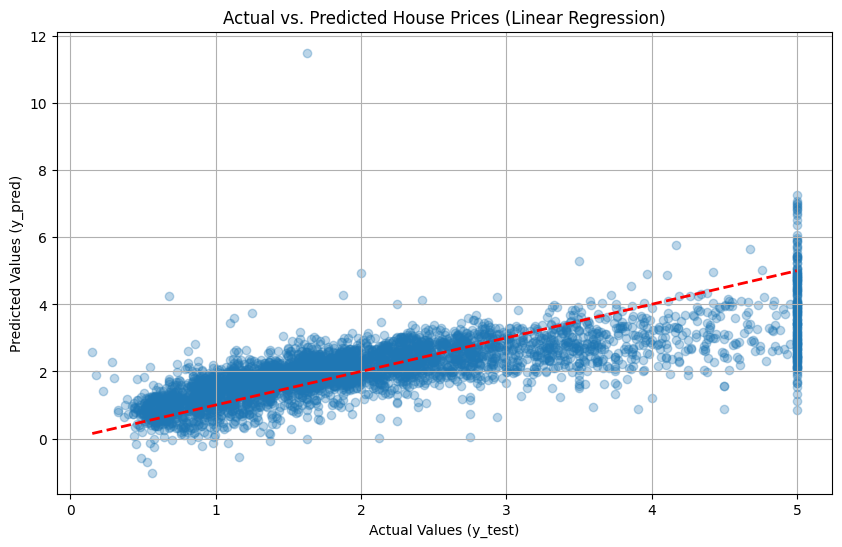

Plot displayed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # Using California Housing as a suitable alternative
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Load the Dataset ---
# Simple explanation: Get the data we'll work with.
# Detail: fetch_california_housing() downloads and loads the California Housing dataset.
# The 'data' part contains the features (like number of rooms, location, etc.),
# and the 'target' part contains the house prices (what we want to predict).
print("Step 1: Loading the dataset...")
housing = fetch_california_housing(as_frame=True)
X = housing.data  # Features
y = housing.target # Target variable (house prices)
print("Dataset loaded successfully.")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# --- 2. Split Data into Training and Testing Sets ---
# Simple explanation: Divide our data into two groups: one for teaching the model,
# and one for testing how well it learned. We'll use 80% for teaching and 20% for testing.
# Detail: train_test_split shuffles the data and then splits it.
# test_size=0.2 means 20% for testing, random_state ensures we get the same split every time we run the code.
print("\nStep 2: Splitting data into training and testing sets (80/20 split)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- 3. Train a Linear Regression Model ---
# Simple explanation: Create our prediction machine (the Linear Regression model)
# and teach it using the training data.
# Detail: LinearRegression() creates an empty model.
# .fit(X_train, y_train) trains the model by finding the best linear relationship
# between the features (X_train) and the target prices (y_train).
print("\nStep 3: Training the Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete.")

# --- 4. Make Predictions on Test Data ---
# Simple explanation: Ask our trained model to predict house prices for the
# data it has never seen (the test set).
# Detail: .predict(X_test) uses the trained model to generate predictions
# for the features in the test set.
print("\nStep 4: Making predictions on the test data...")
y_pred = model.predict(X_test)
print("Predictions made.")

# --- 5. Calculate Evaluation Metrics (RMSE, MAE, R²) ---
# Simple explanation: Check how good our predictions are by comparing them
# to the actual house prices in the test set.
# Detail: We use specific functions from scikit-learn to calculate these metrics.
# mean_squared_error calculates the MSE; we take its square root for RMSE.
# mean_absolute_error calculates MAE.
# r2_score calculates R-squared.
print("\nStep 5: Calculating evaluation metrics...")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# --- 6. Plot Predicted vs. Actual Values ---
# Simple explanation: Draw a graph to visually see how close our predicted
# prices are to the actual prices.
# Detail: We use matplotlib.pyplot to create a scatter plot.
# Each point represents a house from the test set, with its actual price
# on the x-axis and the model's predicted price on the y-axis.
# The red line represents what a perfect prediction would look like (predicted = actual).
print("\nStep 6: Plotting predicted vs. actual values...")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted House Prices (Linear Regression)")
plt.grid(True)
plt.show()
print("Plot displayed.")

Step 1: Loading the dataset...
Dataset loaded successfully.
Number of samples: 20640
Number of features: 8

Step 2: Splitting data into training and testing sets (80/20 split)...
Training set size: 16512 samples
Testing set size: 4128 samples

Step 3: Generating polynomial features (degree=2)...
Original number of features: 8
Number of features after polynomial transformation: 44

Step 4: Training the Linear Regression model on polynomial features...
Polynomial model training complete.

Step 5: Making predictions on the transformed test data...
Predictions made.

Step 6: Calculating evaluation metrics for Polynomial Regression...
Polynomial Regression RMSE: 0.68
Polynomial Regression MAE: 0.47
Polynomial Regression R-squared (R²): 0.65

Step 7: Plotting predicted vs. actual values for Polynomial Regression...


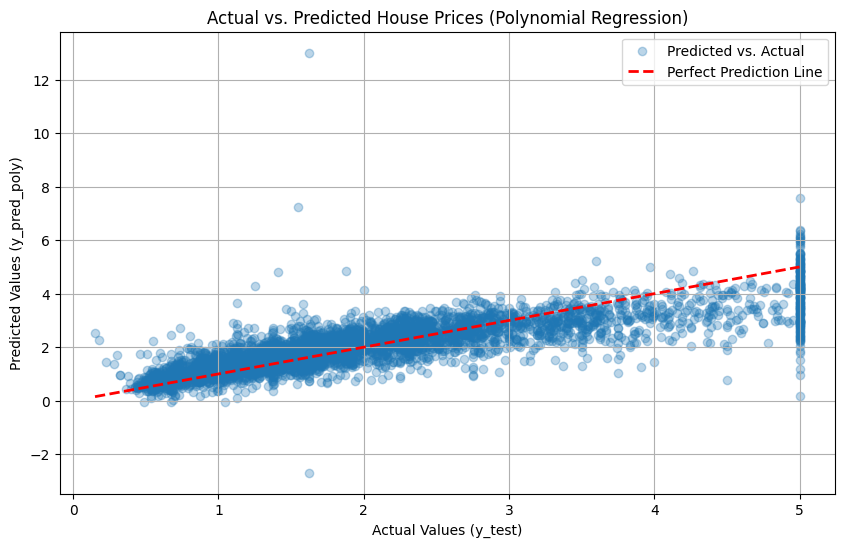

Plot displayed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # Using California Housing dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures # New import for Polynomial Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd # To help with feature names for plotting

# --- 1. Load the Dataset ---
# Simple explanation: Get the housing data we'll work with.
# Detail: fetch_california_housing() loads the California Housing dataset, which contains
# features of houses and their median values (prices).
print("Step 1: Loading the dataset...")
housing = fetch_california_housing(as_frame=True)
X = housing.data  # Features (e.g., median income, average rooms)
y = housing.target # Target variable (median house value in 100k USD)
print("Dataset loaded successfully.")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# --- 2. Split Data into Training and Testing Sets ---
# Simple explanation: Divide our data into two groups: 80% for teaching the model
# (training) and 20% for checking how well it learned (testing).
# Detail: train_test_split shuffles the data and splits it.
# test_size=0.2 means 20% of the data goes to the test set.
# random_state=42 ensures that the split is the same every time you run the code,
# which helps in reproducing results.
print("\nStep 2: Splitting data into training and testing sets (80/20 split)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- 3. Experiment with Polynomial Features ---
# Simple explanation: Before training, we'll create new "curvy" versions of our
# existing features. For example, if we have 'house size', we'll also create
# 'house size squared' and 'house size cubed' (if degree=3).
# Detail: PolynomialFeatures transforms the input features.
# degree=2 means it will create all polynomial combinations of degree 2 or less.
# For example, if you have features A and B, it will create A, B, A^2, B^2, and A*B.
# .fit_transform() learns the transformation from the training data and applies it.
# .transform() applies the *same* learned transformation to the test data.
# It's crucial to fit only on training data to avoid data leakage.
print("\nStep 3: Generating polynomial features (degree=2)...")
poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False prevents adding a column of all ones
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after polynomial transformation: {X_train_poly.shape[1]}")

# You can inspect the new feature names (optional, for understanding)
# poly_feature_names = poly.get_feature_names_out(X.columns)
# print("Example of new polynomial feature names:", poly_feature_names[:5]) # Show first 5

# --- 4. Train a Linear Regression Model on Polynomial Features ---
# Simple explanation: Now, we train our "straight-line" model, but we give it
# the new, "curvy" features we just created. This makes the overall model fit a curve.
# Detail: We instantiate LinearRegression again and fit it to the *transformed*
# training data (X_train_poly) and the original target values (y_train).
print("\nStep 4: Training the Linear Regression model on polynomial features...")
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
print("Polynomial model training complete.")

# --- 5. Make Predictions on Transformed Test Data ---
# Simple explanation: Ask our trained polynomial model to predict house prices
# for the transformed test data.
# Detail: .predict(X_test_poly) uses the model to generate predictions based on
# the polynomial features of the test set.
print("\nStep 5: Making predictions on the transformed test data...")
y_pred_poly = poly_model.predict(X_test_poly)
print("Predictions made.")

# --- 6. Calculate Evaluation Metrics (RMSE, MAE, R²) ---
# Simple explanation: Check how good our curved predictions are by comparing them
# to the actual house prices in the test set.
# Detail: We use the same evaluation metrics as before, but now comparing
# y_test (actual values) with y_pred_poly (predictions from the polynomial model).
print("\nStep 6: Calculating evaluation metrics for Polynomial Regression...")
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression RMSE: {rmse_poly:.2f}")
print(f"Polynomial Regression MAE: {mae_poly:.2f}")
print(f"Polynomial Regression R-squared (R²): {r2_poly:.2f}")

# --- 7. Plot Predicted vs. Actual Values ---
# Simple explanation: Draw a graph to visually see how close our predicted
# prices from the polynomial model are to the actual prices.
# Detail: A scatter plot is created where each point represents a house from the test set.
# The x-axis is the actual house price, and the y-axis is the predicted house price.
# The red dashed line represents the ideal scenario where predicted = actual.
print("\nStep 7: Plotting predicted vs. actual values for Polynomial Regression...")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.3, label='Predicted vs. Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred_poly)")
plt.title("Actual vs. Predicted House Prices (Polynomial Regression)")
plt.grid(True)
plt.legend()
plt.show()
print("Plot displayed.")